In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [30]:
df = pd.read_csv("/home/wieger/Documents/Research/Omnisketch/omni/input/pointQueries/CAIDA/queries_withDeletes_spreadOut_actDelPerc=0.9_maxDelPerc=0.9_CAIDA_numStoredAttrs_5_queriesFromDomain_true_orgN10433575_numQueries_189.csv")

In [31]:
df.columns

Index(['numStoredAttributes', 'queryId', 'query', 'numPreds', 'binNumber',
       'exactAnswer', 'unionSize', 'exactDeletes', 'unionDeletes'],
      dtype='object')

In [32]:
df['exactAnswer'].max()

20835

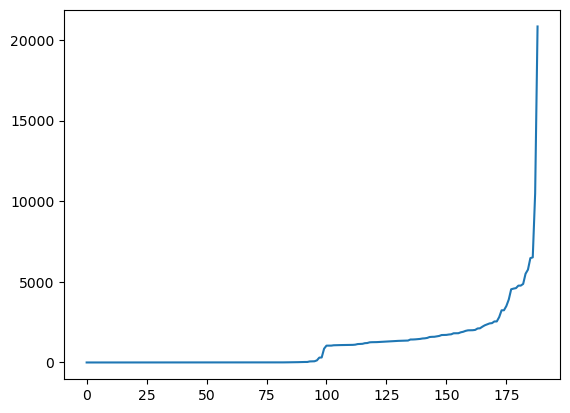

In [33]:
plt.plot(sorted(df['exactAnswer']))

In [34]:
#df_ram = df_2lhs[df_2lhs['RAM'] == df_2lhs['RAM'].min()]
# Calculate mean and std per 'binNumber'
grouped = df.groupby(['binNumber'])['exactAnswer'].agg(['count','mean', 'std']).reset_index()
grouped

,binNumber,count,mean,std
0,0,100,21.490000,95.996685
1,1,63,1421.666667,293.013927
2,2,10,2388.700000,215.759666
3,3,4,3470.750000,315.402785
4,4,6,4689.500000,130.397469
5,5,2,5630.500000,180.312229
6,6,2,6495.000000,33.941125
7,7,1,10495.000000,NaN
8,8,1,20835.000000,NaN


In [18]:
df = pd.read_csv("/home/wieger/Documents/Research/Omnisketch/omni/input/data/CAIDA/equinix-chicago.dirA.20110217-125904.UTC.anon.pcap.csv")

In [19]:
df

,frame.number,frame.time,eth.src,eth.dst,ip.src,ip.dst,ip.proto
0,1,"Feb 17, 2011 13:59:04.112376000 CET",NaN,NaN,254.135.182.194,205.42.29.69,6.0
1,2,"Feb 17, 2011 13:59:04.112380000 CET",NaN,NaN,112.247.0.252,63.242.59.154,17.0
2,3,"Feb 17, 2011 13:59:04.112385000 CET",NaN,NaN,113.119.246.64,37.30.65.18,6.0
3,4,"Feb 17, 2011 13:59:04.112419000 CET",NaN,NaN,38.186.115.25,55.67.79.64,6.0
4,5,"Feb 17, 2011 13:59:04.112436000 CET",NaN,NaN,35.83.196.13,43.202.33.108,6.0
...,...,...,...,...,...,...,...
5077339,5077340,"Feb 17, 2011 13:59:59.999976000 CET",NaN,NaN,34.98.16.238,94.166.63.31,6.0
5077340,5077341,"Feb 17, 2011 13:59:59.999983000 CET",NaN,NaN,39.157.253.52,42.141.96.242,6.0
5077341,5077342,"Feb 17, 2011 13:59:59.999988000 CET",NaN,NaN,241.105.38.253,42.252.4.254,6.0
5077342,5077343,"Feb 17, 2011 13:59:59.999997000 CET",NaN,NaN,58.216.174.198,195.200.100.82,6.0


In [82]:
def preprocess_caida(df):
    df1 = df.copy()
    df1['ipSrcNet'] = '-1'
    df1['ipSrcHost'] = '-1'
    df1['ipDstNet'] = '-1'
    df1['ipDstHost'] = '-1'
    for k, v in df.iterrows():
        if (isinstance(v['ip.src'], float) or pd.isnull(v['ip.src'])):
            continue
        
        src = v['ip.src'].split('.')
        df1.loc[k, 'ipSrcNet'] = '.'.join(src[:2])
        df1.loc[k, 'ipSrcHost'] = '.'.join(src[2:])
        if (isinstance(v['ip.dst'], float) or pd.isnull(v['ip.dst'])):
            continue
        dst = v['ip.dst'].split('.')
        df1.loc[k, 'ipDstHost'] = '.'.join(dst[2:])
        df1.loc[k, 'ipDstNet'] = '.'.join(dst[:2])
    return df1

In [83]:
df1 = preprocess_caida(df)

In [84]:
for i in df1.columns:
    print("unique of {} is {}".format(i, len(df1[i].unique())))

unique of frame.number is 5077344
unique of frame.time is 4588960
unique of eth.src is 1
unique of eth.dst is 1
unique of ip.src is 117946
unique of ip.dst is 86835
unique of ip.proto is 7
unique of ipSrcNet is 3537
unique of ipSrcHost is 54675
unique of ipDstNet is 1005
unique of ipDstHost is 47817


In [5]:
len(df['ip.src'].unique())

117946

In [8]:
len(df['ip.dst'].unique())

86835

In [11]:
df['ip.proto'].value_counts()

6.0     4072646
17.0     983650
1.0       17020
47.0       2172
50.0       1555
41.0         38
Name: ip.proto, dtype: int64

In [44]:
# df = pd.read_csv("./output/pointQueries/CAIDA/results_Delete Stream_CAIDA_2023-12-07 16:52:11_Rep1.csv")
#df = pd.read_csv("./output/pointQueries/CAIDA/results_Delete Stream_CAIDA_2023-12-08 09:29:53_Rep1.csv")
#df = pd.read_csv("./output/pointQueries/CAIDA/results_Delete Stream_CAIDA_2023-12-11 09:34:01_Rep1.csv")
df = pd.read_csv("/home/wieger/Documents/Research/Omnisketch/omni/output/pointQueries/CAIDA/results_Delete Stream_CAIDA_2023-12-12 11:22:49_Rep2.csv")

In [45]:
df.columns

Index(['streamSize', 'numAttributes', 'memUsageDataset', 'RAM', 'setting',
       'Avg Update Time', 'memUsageSynopsis', 'parameters',
       'numAttributesInWorkload', 'queryID', 'numPredicates', 'exactAnswer',
       'estimate', 'absError', 'relError', 'epsError', 'withinThreshold',
       'estTime', 'queryText', 'estimateResidu', 'absErrorResidu',
       'relErrorResidu', 'epsErrorResidu', 'withinThresholdResidu',
       'numNoiseRecords', 'numCleanRecords'],
      dtype='object')

In [46]:
df['numPredicates'].value_counts()

3    5100
2    4950
4    2550
1    1890
5     510
Name: numPredicates, dtype: int64

In [47]:
df['RAM'].min()

80000000

In [48]:
df['RAM'].value_counts()

80000000     5000
400000000    5000
800000000    5000
Name: RAM, dtype: int64

In [54]:
df['epsIfZero'] = df['exactAnswer']/df['numCleanRecords']

In [55]:
df.columns

Index(['streamSize', 'numAttributes', 'memUsageDataset', 'RAM', 'setting',
       'Avg Update Time', 'memUsageSynopsis', 'parameters',
       'numAttributesInWorkload', 'queryID', 'numPredicates', 'exactAnswer',
       'estimate', 'absError', 'relError', 'epsError', 'withinThreshold',
       'estTime', 'queryText', 'estimateResidu', 'absErrorResidu',
       'relErrorResidu', 'epsErrorResidu', 'withinThresholdResidu',
       'numNoiseRecords', 'numCleanRecords', 'epsIfZero'],
      dtype='object')

In [42]:
grouped_data = df.groupby(['RAM', 'numNoiseRecords'])[['epsError', 'epsErrorResidu']].mean().reset_index()
grouped_data

,RAM,numNoiseRecords,epsError,epsErrorResidu
0,80000000,1000000,0.000547,0.000293
1,80000000,5000000,0.000887,0.000293
2,80000000,10000000,0.001373,0.000293
3,80000000,15000000,0.001797,0.000293
4,80000000,20000000,0.002031,0.000293
5,400000000,1000000,0.000188,0.000113
6,400000000,5000000,0.000340,0.000113
7,400000000,10000000,0.000444,0.000113
8,400000000,15000000,0.000583,0.000113
9,400000000,20000000,0.000547,0.000113


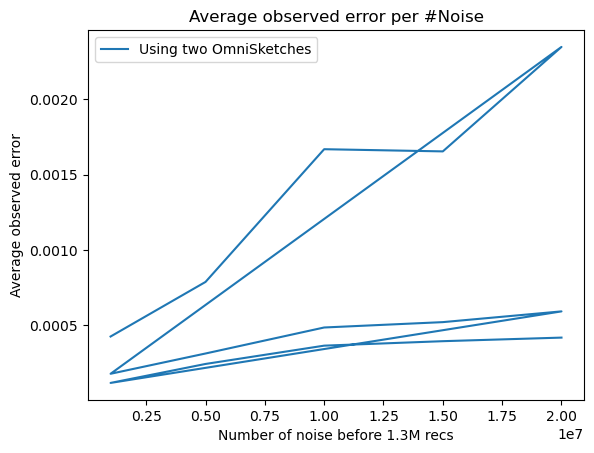

In [25]:
# Group by 'RAM' and calculate the mean of 'epsError' and 'epsErrorResidu'
grouped_data = df.groupby(['RAM', 'numNoiseRecords'])[['epsError', 'epsErrorResidu']].mean().reset_index()
colors = {}
choose_from = ['black', 'blue', 'red', 'green']
uniq_ram = df['RAM'].unique()
for i in range(len(uniq_ram)):
    colors[uniq_ram[i]] = choose_from[i]

# Plotting
plt.plot(grouped_data['numNoiseRecords'], grouped_data['epsError'],
         label='Using two OmniSketches')
#plt.plot(grouped_data['numNoiseRecords'], grouped_data['epsErrorResidu'], label='Using one on Residu')

# Adding labels and title
plt.xlabel('Number of noise before 1.3M recs')
plt.ylabel('Average observed error')
plt.title('Average observed error per #Noise')
plt.legend()

# Display the plot
plt.show()

In [69]:
for i, v in df[df['epsError'] == df['epsError'].max()].iterrows():
    print(v, i)

streamSize                         21343709
numAttributes                            11
memUsageDataset                  5159839104
RAM                                80000000
setting                          OmniSketch
Avg Update Time                        1145
memUsageSynopsis                  112077481
parameters                 [3, 8, 2752, 24]
numAttributesInWorkload                   5
queryID                                  15
numPredicates                             1
exactAnswer                         1072398
estimate                              -5621
absError                            1078019
relError                           1.005242
epsError                           0.802271
withinThreshold                       False
estTime                                   1
queryText                       ipProto=6, 
estimateResidu                      1083970
absErrorResidu                        11572
relErrorResidu                     0.010791
epsErrorResidu                  

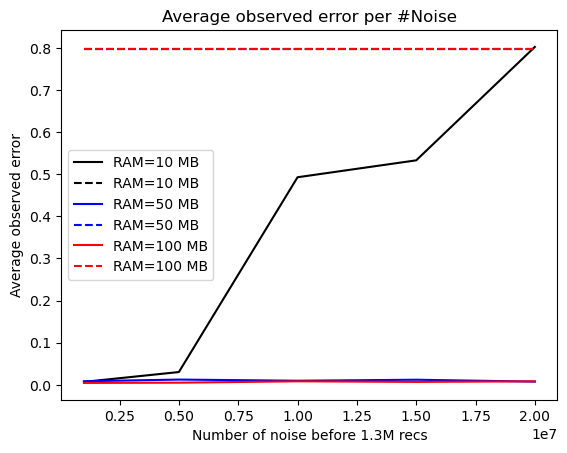

In [60]:
# Assuming you have already grouped the data as mentioned in your code
grouped_data = df.groupby(['RAM', 'numNoiseRecords'])[['epsError', 'epsErrorResidu', 'epsIfZero']].max().reset_index()

# Create a color dictionary for each unique RAM value
colors = {}
choose_from = ['black', 'blue', 'red', 'green']
uniq_ram = df['RAM'].unique()
for i in range(len(uniq_ram)):
    colors[uniq_ram[i]] = choose_from[i]

# Plotting with assigned colors
for ram, color in colors.items():
    ram_data = grouped_data[grouped_data['RAM'] == ram]
    plt.plot(ram_data['numNoiseRecords'], ram_data['epsError'], label=f'RAM={str(ram/(8e6)).replace(".0", "")} MB', color=color)
    plt.plot(ram_data['numNoiseRecords'], ram_data['epsIfZero'], label=f'RAM={str(ram/(8e6)).replace(".0", "")} MB',
             linestyle='--',color=color)
    
# Adding labels and title
plt.xlabel('Number of noise before 1.3M recs')
plt.ylabel('Average observed error')
plt.title('Average observed error per #Noise')
plt.legend()

# Display the plot
plt.show()

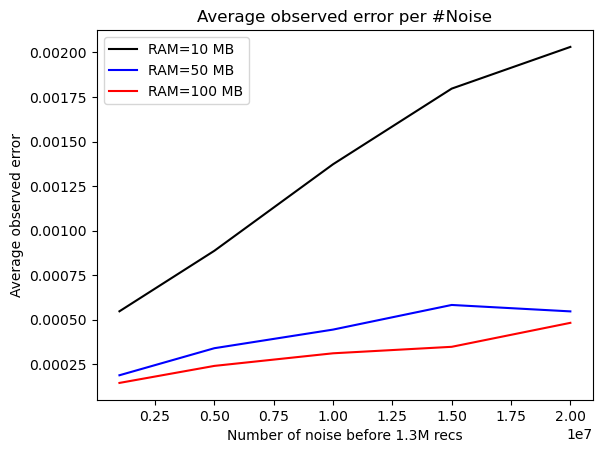

In [58]:
# Assuming you have already grouped the data as mentioned in your code
grouped_data = df.groupby(['RAM', 'numNoiseRecords'])[['epsError', 'epsErrorResidu']].mean().reset_index()

# Create a color dictionary for each unique RAM value
colors = {}
choose_from = ['black', 'blue', 'red', 'green']
uniq_ram = df['RAM'].unique()
for i in range(len(uniq_ram)):
    colors[uniq_ram[i]] = choose_from[i]

# Plotting with assigned colors
for ram, color in colors.items():
    ram_data = grouped_data[grouped_data['RAM'] == ram]
    plt.plot(ram_data['numNoiseRecords'], ram_data['epsError'], label=f'RAM={str(ram/(8e6)).replace(".0", "")} MB', color=color)

# Adding labels and title
plt.xlabel('Number of noise before 1.3M recs')
plt.ylabel('Average observed error')
plt.title('Average observed error per #Noise')
plt.legend()

# Display the plot
plt.show()

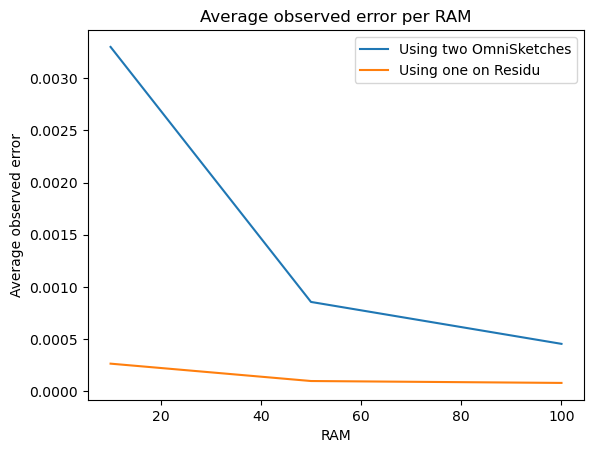

In [29]:
# Group by 'RAM' and calculate the mean of 'epsError' and 'epsErrorResidu'
grouped_data = df.groupby('RAM')[['epsError', 'epsErrorResidu']].mean().reset_index()

# Plotting
plt.plot(grouped_data['RAM']/(8e6), grouped_data['epsError'], label='Using two OmniSketches')
plt.plot(grouped_data['RAM']/(8e6), grouped_data['epsErrorResidu'], label='Using one on Residu')

# Adding labels and title
plt.xlabel('RAM')
plt.ylabel('Average observed error')
plt.title('Average observed error per RAM')
plt.legend()

# Display the plot
plt.show()

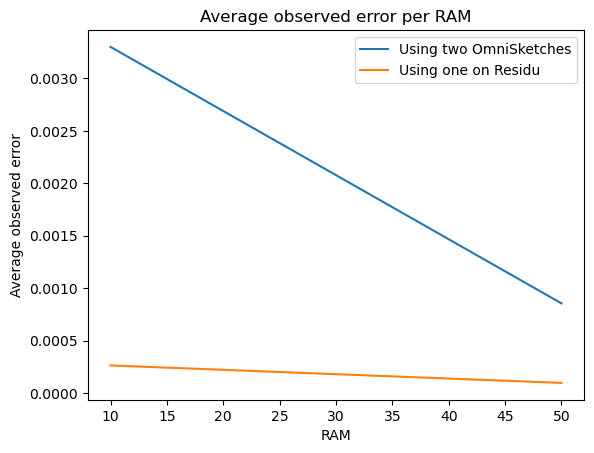

In [9]:
# Group by 'RAM' and calculate the mean of 'epsError' and 'epsErrorResidu'
grouped_data = df.groupby('RAM')[['epsError', 'epsErrorResidu']].mean().reset_index()

# Plotting
plt.plot(grouped_data['RAM']/(8e6), grouped_data['epsError'], label='Using two OmniSketches')
plt.plot(grouped_data['RAM']/(8e6), grouped_data['epsErrorResidu'], label='Using one on Residu')

# Adding labels and title
plt.xlabel('RAM')
plt.ylabel('Average observed error')
plt.title('Average observed error per RAM')
plt.legend()

# Display the plot
plt.show()

In [127]:
26874162*0.05

1343708.1

In [22]:
oneRam = df[df['RAM'] == df['RAM'].iloc[-1]]

In [23]:
oneRam['numPredicates'].value_counts()

3    340
2    330
4    170
1    126
5     34
Name: numPredicates, dtype: int64

<Axes: >

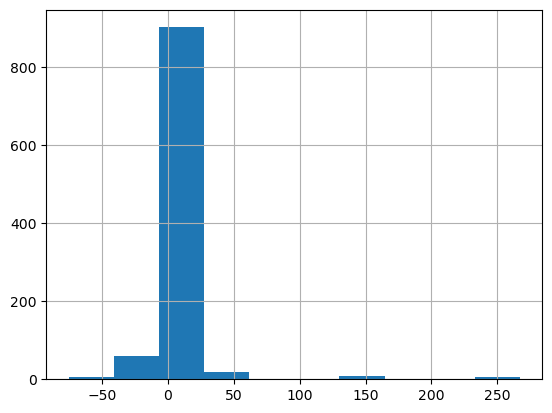

In [26]:
oneRam['estimate'].hist()

In [28]:
oneRam['estimate']

2000    25
2001   -15
2002    17
2003     4
2004    25
        ..
2995     2
2996     0
2997     0
2998     0
2999     0
Name: estimate, Length: 1000, dtype: int64

In [46]:
caida = pd.read_csv("/home/wieger/Documents/Research/Omnisketch/omni/input/data/CAIDA/equinix-chicago.dirA.20110217-125904.UTC.anon.pcap.csv")

<Axes: >

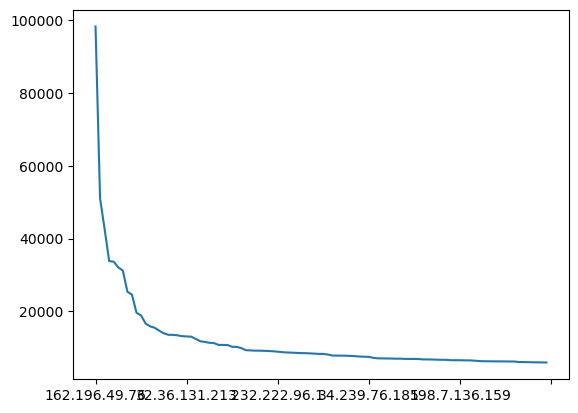

In [77]:
(caida['ip.src'].value_counts())[0:100].plot()

In [57]:
numUpdates = len(caida.index)*0.01

In [68]:
res = caida.iloc[len(caida.index) - int(numUpdates):,:]

<Axes: >

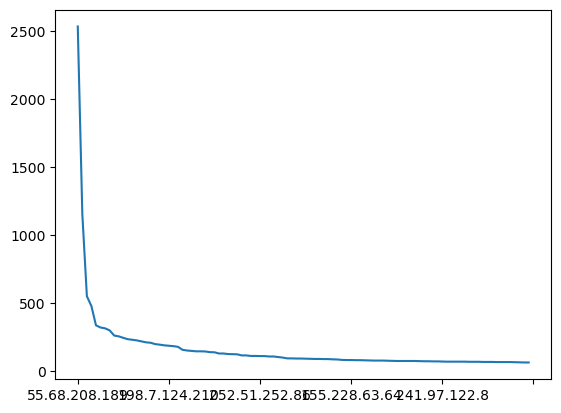

In [76]:
(res['ip.src'].value_counts())[0:100].plot()

## Using two omnis

In [39]:
df['epsError'].describe()

count    1.000000e+03
mean     9.011406e-06
std      1.510470e-05
min      0.000000e+00
25%      9.355287e-07
50%      3.348208e-06
75%      1.073396e-05
max      2.062102e-04
Name: epsError, dtype: float64

In [40]:
df['relError'].describe()

count    1000.000000
mean        2.125608
std         9.659165
min         0.000000
25%         0.244380
50%         0.600000
75%         1.000000
max        84.000000
Name: relError, dtype: float64

In [41]:
# avg obs error / ram size


## Using one omnisketch on the updates that are not deleted

In [42]:
df['epsErrorResidu'].describe()

count    1.000000e+03
mean     1.106858e-05
std      4.372166e-05
min      0.000000e+00
25%      0.000000e+00
50%      3.939068e-07
75%      5.514695e-06
max      7.192738e-04
Name: epsErrorResidu, dtype: float64

In [43]:
df['relErrorResidu'].describe()

count    1000.000000
mean        0.371934
std         0.401434
min         0.000000
25%         0.000000
50%         0.017699
75%         0.785714
max         3.000000
Name: relErrorResidu, dtype: float64